## Ячейка 1: Импорты и настройка папок

In [4]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Создаем структуру папок для артефактов
ARTIFACTS_DIR = "artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Папки {ARTIFACTS_DIR} и {FIGURES_DIR} готовы!")

# Список для сбора результатов экспериментов
runs_results =[]

Папки artifacts и artifacts/figures готовы!


## Ячейка 2: Seed и выбор устройства (Device)

In [5]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


## Ячейка 3: Загрузка данных EMNIST

In [7]:
# Transform: просто переводим в тензор (значения будут от 0 до 1)
transform = transforms.Compose([
    transforms.ToTensor()
])

# Загружаем датасет EMNIST (split="balanced")
full_train_dataset = datasets.EMNIST(root='./data', split='balanced', train=True, download=True, transform=transform)
test_dataset = datasets.EMNIST(root='./data', split='balanced', train=False, download=True, transform=transform)

# Разбиение train/val (80% / 20%)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Используем генератор с зафиксированным seed для воспроизводимости сплита
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=generator)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Sanity-check
for x_batch, y_batch in train_loader:
    print(f"Размер батча (X): {x_batch.shape}")
    print(f"Размер батча (Y): {y_batch.shape}")
    print(f"Диапазон значений X:[{x_batch.min():.4f}, {x_batch.max():.4f}]")
    print(f"Количество уникальных классов в батче: {len(torch.unique(y_batch))}")
    break

100%|██████████| 562M/562M [00:07<00:00, 72.0MB/s]


Размер батча (X): torch.Size([128, 1, 28, 28])
Размер батча (Y): torch.Size([128])
Диапазон значений X:[0.0000, 1.0000]
Количество уникальных классов в батче: 45


## Ячейка 4: Определение модели (MLP)

In [8]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=[256, 128], dropout_p=0.0, use_batchnorm=False):
        super(MLP, self).__init__()
        layers =[]
        in_features = 28 * 28 # Исходный размер картинки 28x28

        # Flatten слой
        self.flatten = nn.Flatten()

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(in_features, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            if dropout_p > 0.0:
                layers.append(nn.Dropout(p=dropout_p))
            in_features = hidden_size

        # Выходной слой на 47 классов (EMNIST Balanced)
        layers.append(nn.Linear(in_features, 47))
        self.network = nn.Sequential(*layers)

        self.config_summary = f"Hidden:{hidden_sizes}|BN:{use_batchnorm}|Drop:{dropout_p}"

    def forward(self, x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits

## Ячейка 5: Функции для обучения (Train, Eval) и Early Stopping

In [9]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            running_loss += loss.item() * x.size(0)

            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

def train_model(model, train_loader, val_loader, optimizer, epochs, device, patience=None):
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc':[], 'val_loss': [], 'val_acc':[]}

    best_val_acc = 0.0
    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0
    epochs_trained = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        epochs_trained += 1

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if patience is not None and epochs_no_improve >= patience:
            print(f"EarlyStopping сработал на эпохе {epoch+1}")
            break

    return history, best_val_acc, best_val_loss, best_model_state, epochs_trained

## Ячейка 6: Часть A - Базовые эксперименты (E1, E2, E3)

In [10]:
def run_experiment(exp_id, model, optimizer_name, lr, momentum, weight_decay, epochs, patience=None):
    set_seed(SEED)
    model = model.to(device)

    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

    print(f"\n--- Запуск {exp_id}: {model.config_summary} | {optimizer_name} lr={lr} ---")
    history, best_acc, best_loss, best_state, ep_trained = train_model(
        model, train_loader, val_loader, optimizer, epochs, device, patience
    )

    runs_results.append({
        'experiment_id': exp_id,
        'dataset': 'EMNIST',
        'seed': SEED,
        'model_summary': model.config_summary,
        'optimizer': optimizer_name,
        'lr': lr,
        'momentum': momentum if optimizer_name == 'SGD' else 0,
        'weight_decay': weight_decay,
        'epochs_trained': ep_trained,
        'best_val_accuracy': best_acc,
        'best_val_loss': best_loss
    })

    return history, best_state, best_acc

# Общие настройки для Части A
A_EPOCHS = 10
LR = 1e-3

# E1 (base)
model_e1 = MLP(hidden_sizes=[256, 128], dropout_p=0.0, use_batchnorm=False)
hist_e1, _, acc_e1 = run_experiment('E1', model_e1, 'Adam', LR, 0, 0, A_EPOCHS)

# E2 (Dropout)
model_e2 = MLP(hidden_sizes=[256, 128], dropout_p=0.3, use_batchnorm=False)
hist_e2, _, acc_e2 = run_experiment('E2', model_e2, 'Adam', LR, 0, 0, A_EPOCHS)

# E3 (BatchNorm)
model_e3 = MLP(hidden_sizes=[256, 128], dropout_p=0.0, use_batchnorm=True)
hist_e3, _, acc_e3 = run_experiment('E3', model_e3, 'Adam', LR, 0, 0, A_EPOCHS)


--- Запуск E1: Hidden:[256, 128]|BN:False|Drop:0.0 | Adam lr=0.001 ---
Epoch 01/10 | Train Loss: 1.2812 Acc: 0.6375 | Val Loss: 0.8431 Acc: 0.7465
Epoch 02/10 | Train Loss: 0.7059 Acc: 0.7791 | Val Loss: 0.6535 Acc: 0.7944
Epoch 03/10 | Train Loss: 0.5727 Acc: 0.8137 | Val Loss: 0.5818 Acc: 0.8090
Epoch 04/10 | Train Loss: 0.5010 Acc: 0.8325 | Val Loss: 0.5426 Acc: 0.8218
Epoch 05/10 | Train Loss: 0.4544 Acc: 0.8449 | Val Loss: 0.5155 Acc: 0.8299
Epoch 06/10 | Train Loss: 0.4208 Acc: 0.8530 | Val Loss: 0.5027 Acc: 0.8357
Epoch 07/10 | Train Loss: 0.3925 Acc: 0.8614 | Val Loss: 0.4937 Acc: 0.8368
Epoch 08/10 | Train Loss: 0.3691 Acc: 0.8682 | Val Loss: 0.5041 Acc: 0.8323
Epoch 09/10 | Train Loss: 0.3474 Acc: 0.8743 | Val Loss: 0.4882 Acc: 0.8406
Epoch 10/10 | Train Loss: 0.3282 Acc: 0.8802 | Val Loss: 0.4869 Acc: 0.8446

--- Запуск E2: Hidden:[256, 128]|BN:False|Drop:0.3 | Adam lr=0.001 ---
Epoch 01/10 | Train Loss: 1.5648 Acc: 0.5514 | Val Loss: 0.8597 Acc: 0.7431
Epoch 02/10 | Train 

## Ячейка 7: Часть A - Выбор лучшего и E4 (Early Stopping)


Лучший среди регуляризаций (E2 vs E3): E3

--- Запуск E4: Hidden:[256, 128]|BN:True|Drop:0.0 | Adam lr=0.001 ---
Epoch 01/20 | Train Loss: 0.9983 Acc: 0.7280 | Val Loss: 0.6023 Acc: 0.8098
Epoch 02/20 | Train Loss: 0.5313 Acc: 0.8245 | Val Loss: 0.5345 Acc: 0.8219
Epoch 03/20 | Train Loss: 0.4487 Acc: 0.8463 | Val Loss: 0.4897 Acc: 0.8349
Epoch 04/20 | Train Loss: 0.4033 Acc: 0.8585 | Val Loss: 0.4701 Acc: 0.8433
Epoch 05/20 | Train Loss: 0.3690 Acc: 0.8682 | Val Loss: 0.4612 Acc: 0.8480
Epoch 06/20 | Train Loss: 0.3430 Acc: 0.8745 | Val Loss: 0.4612 Acc: 0.8488
Epoch 07/20 | Train Loss: 0.3212 Acc: 0.8814 | Val Loss: 0.4600 Acc: 0.8498
Epoch 08/20 | Train Loss: 0.3030 Acc: 0.8864 | Val Loss: 0.4687 Acc: 0.8459
Epoch 09/20 | Train Loss: 0.2857 Acc: 0.8915 | Val Loss: 0.4673 Acc: 0.8493
Epoch 10/20 | Train Loss: 0.2722 Acc: 0.8958 | Val Loss: 0.4803 Acc: 0.8484
Epoch 11/20 | Train Loss: 0.2599 Acc: 0.8998 | Val Loss: 0.4812 Acc: 0.8492
EarlyStopping сработал на эпохе 11


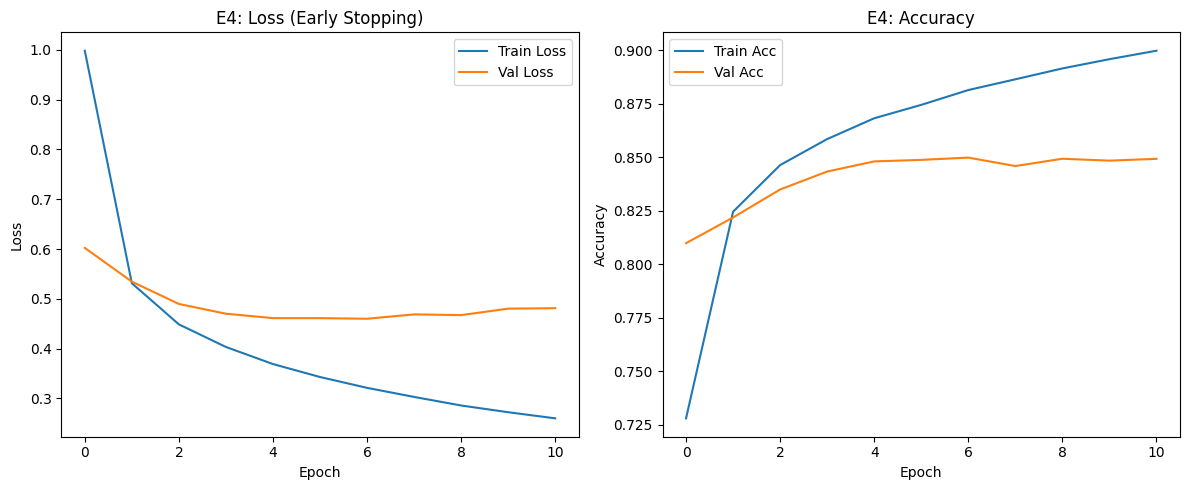

In [11]:
# Выбор победителя из E2 и E3
best_e2_e3 = 'E2' if acc_e2 > acc_e3 else 'E3'
print(f"\nЛучший среди регуляризаций (E2 vs E3): {best_e2_e3}")

use_drop = 0.3 if best_e2_e3 == 'E2' else 0.0
use_bn = True if best_e2_e3 == 'E3' else False

# E4 (Лучшая модель домашки с EarlyStopping)
model_e4 = MLP(hidden_sizes=[256, 128], dropout_p=use_drop, use_batchnorm=use_bn)
hist_e4, state_e4, acc_e4 = run_experiment('E4', model_e4, 'Adam', LR, 0, 0, epochs=20, patience=4)

# Сохраняем модель и конфиг (Артефакты)
torch.save(state_e4, os.path.join(ARTIFACTS_DIR, 'best_model.pt'))

best_config = {
    'dataset': 'EMNIST',
    'seed': SEED,
    'hidden_sizes': [256, 128],
    'dropout_p': use_drop,
    'use_batchnorm': use_bn,
    'optimizer': 'Adam',
    'lr': LR,
    'best_val_accuracy': acc_e4
}
with open(os.path.join(ARTIFACTS_DIR, 'best_config.json'), 'w') as f:
    json.dump(best_config, f, indent=4)

# Рисуем и сохраняем график для E4
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_e4['train_loss'], label='Train Loss')
plt.plot(hist_e4['val_loss'], label='Val Loss')
plt.title("E4: Loss (Early Stopping)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_e4['train_acc'], label='Train Acc')
plt.plot(hist_e4['val_acc'], label='Val Acc')
plt.title("E4: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'curves_best.png'))
plt.show()

## Ячейка 8: Часть B - Экстремальные LR и SGD (O1, O2, O3)


--- Запуск O1: Hidden:[256, 128]|BN:True|Drop:0.0 | Adam lr=0.1 ---
Epoch 01/05 | Train Loss: 1.0785 Acc: 0.6733 | Val Loss: 0.7850 Acc: 0.7533
Epoch 02/05 | Train Loss: 0.7850 Acc: 0.7509 | Val Loss: 0.7730 Acc: 0.7532
Epoch 03/05 | Train Loss: 0.7014 Acc: 0.7726 | Val Loss: 0.6719 Acc: 0.7853
Epoch 04/05 | Train Loss: 0.6524 Acc: 0.7867 | Val Loss: 0.6836 Acc: 0.7752
Epoch 05/05 | Train Loss: 0.6271 Acc: 0.7934 | Val Loss: 0.6671 Acc: 0.7807

--- Запуск O2: Hidden:[256, 128]|BN:True|Drop:0.0 | Adam lr=1e-05 ---
Epoch 01/05 | Train Loss: 3.4676 Acc: 0.1785 | Val Loss: 3.1181 Acc: 0.3286
Epoch 02/05 | Train Loss: 2.9200 Acc: 0.4110 | Val Loss: 2.7361 Acc: 0.4758
Epoch 03/05 | Train Loss: 2.6036 Acc: 0.5085 | Val Loss: 2.4615 Acc: 0.5452
Epoch 04/05 | Train Loss: 2.3610 Acc: 0.5639 | Val Loss: 2.2484 Acc: 0.5867
Epoch 05/05 | Train Loss: 2.1575 Acc: 0.5984 | Val Loss: 2.0533 Acc: 0.6152

--- Запуск O3: Hidden:[256, 128]|BN:True|Drop:0.0 | SGD lr=0.01 ---
Epoch 01/12 | Train Loss: 1.115

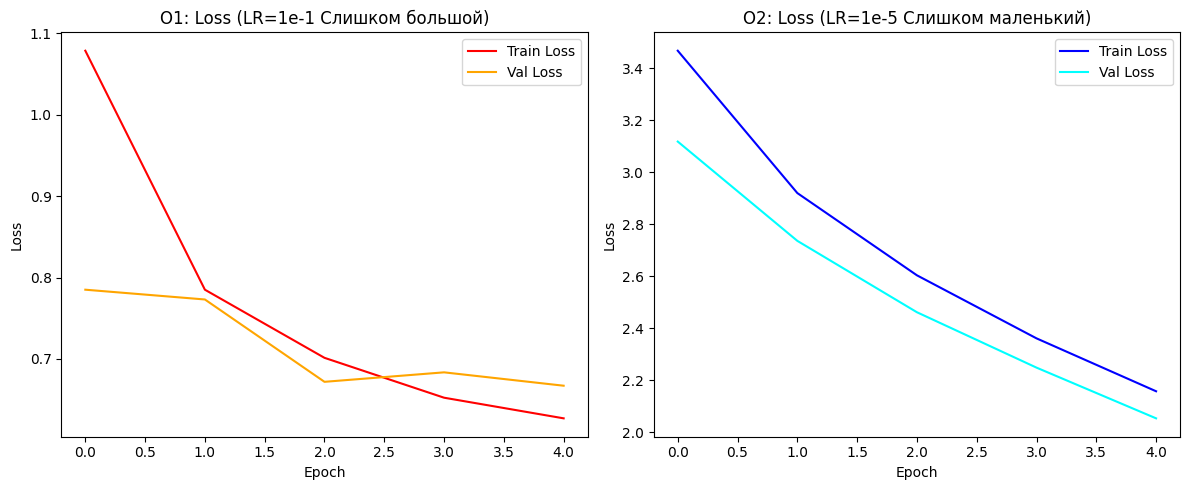

In [12]:
# O1 (Слишком большой LR) - 5 эпох
model_o1 = MLP(hidden_sizes=[256, 128], dropout_p=use_drop, use_batchnorm=use_bn)
hist_o1, _, _ = run_experiment('O1', model_o1, 'Adam', lr=1e-1, momentum=0, weight_decay=0, epochs=5)

# O2 (Слишком маленький LR) - 5 эпох
model_o2 = MLP(hidden_sizes=[256, 128], dropout_p=use_drop, use_batchnorm=use_bn)
hist_o2, _, _ = run_experiment('O2', model_o2, 'Adam', lr=1e-5, momentum=0, weight_decay=0, epochs=5)

# O3 (SGD + Momentum + Weight Decay) - 12 эпох
model_o3 = MLP(hidden_sizes=[256, 128], dropout_p=use_drop, use_batchnorm=use_bn)
hist_o3, _, _ = run_experiment('O3', model_o3, 'SGD', lr=1e-2, momentum=0.9, weight_decay=1e-4, epochs=12)

# Рисуем и сохраняем графики "Плохих LR"
plt.figure(figsize=(12, 5))

# O1 (Большой LR) может уйти в NaN или "скакать", поэтому используем try-except или просто строим
plt.subplot(1, 2, 1)
plt.plot(hist_o1['train_loss'], label='Train Loss', color='red')
plt.plot(hist_o1['val_loss'], label='Val Loss', color='orange')
plt.title("O1: Loss (LR=1e-1 Слишком большой)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_o2['train_loss'], label='Train Loss', color='blue')
plt.plot(hist_o2['val_loss'], label='Val Loss', color='cyan')
plt.title("O2: Loss (LR=1e-5 Слишком маленький)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'curves_lr_extremes.png'))
plt.show()

## Ячейка 9: Сохранение таблицы и финальная оценка на Test

In [13]:
# Сохранение runs.csv
df_runs = pd.DataFrame(runs_results)
df_runs.to_csv(os.path.join(ARTIFACTS_DIR, 'runs.csv'), index=False)
print("\n--- Эксперименты завершены. Таблица runs.csv сохранена. ---")
display(df_runs)

# Финальный шаг: оценка лучшей модели (E4) на Test dataset
best_model = MLP(hidden_sizes=[256, 128], dropout_p=use_drop, use_batchnorm=use_bn)
best_model.load_state_dict(torch.load(os.path.join(ARTIFACTS_DIR, 'best_model.pt')))
best_model.to(device)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)

print("="*50)
print(f"ФИНАЛЬНЫЙ РЕЗУЛЬТАТ (E4) НА ТЕСТОВОЙ ВЫБОРКЕ:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")
print("="*50)


--- Эксперименты завершены. Таблица runs.csv сохранена. ---


,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,"Hidden:[256, 128]|BN:False|Drop:0.0",Adam,0.00100,0.0,0.0000,10,0.844637,0.486869
1,E2,EMNIST,42,"Hidden:[256, 128]|BN:False|Drop:0.3",Adam,0.00100,0.0,0.0000,10,0.837411,0.485127
2,E3,EMNIST,42,"Hidden:[256, 128]|BN:True|Drop:0.0",Adam,0.00100,0.0,0.0000,10,0.848449,0.456805
3,E4,EMNIST,42,"Hidden:[256, 128]|BN:True|Drop:0.0",Adam,0.00100,0.0,0.0000,11,0.849823,0.459990
4,O1,EMNIST,42,"Hidden:[256, 128]|BN:True|Drop:0.0",Adam,0.10000,0.0,0.0000,5,0.785328,0.671911
5,O2,EMNIST,42,"Hidden:[256, 128]|BN:True|Drop:0.0",Adam,0.00001,0.0,0.0000,5,0.615160,2.053289
6,O3,EMNIST,42,"Hidden:[256, 128]|BN:True|Drop:0.0",SGD,0.01000,0.9,0.0001,12,0.849246,0.466019


ФИНАЛЬНЫЙ РЕЗУЛЬТАТ (E4) НА ТЕСТОВОЙ ВЫБОРКЕ:
Test Loss: 0.4713
Test Accuracy: 0.8453 (84.53%)
